# Ptychography Tutorial 03

This is the third tutorial notebook in the iterative ptychography series.  
In this tutorial notebook we will cover:
- Parameter optimization

### Downloads
This tutorial uses the following datasets:
- [ptycho_ducky_simulation_03.h5](https://drive.google.com/file/d/1rCWIokqDGINpex_zYz4ryiiEkfuh1xTI/view?usp=drive_link)
- [ptycho_ducky_vacuum-probe_03.h5](https://drive.google.com/file/d/1aiZbsXU1dUf4RIHZDLUbWsGZlZZAaClM/view?usp=drive_link)

### Acknowledgements

This tutorial was created by the py4DSTEM `phase_contrast` team:
- Steven Zeltmann (steven.zeltmann@lbl.gov)
- Georgios Varnavides (gvarnavides@berkeley.edu)
- Stephanie Ribet (sribet@lbl.gov)
- Colin Ophus (clophus@lbl.gov)

Last updated 2024 May 3

## Parameter Optimization
We have already seen the importance of having accurate calibrations for phase retrieval, and investigated two powerful methods for obtaining good estimates:
- DPC: CoM curl minimization &rarr; rotation estimate
- Parallax: Cross-correlation shifts fitting &rarr; rotation, defocus, astigmatism etc estimates

There are however additional parameters, such as the reciprocal-space pixel-size, sample thickness (multi-slice) etc, which these methods don't inform us about and are of crucial importance to ptychographic reconstructions.

Here, we present a general framework to perform grid-search as-well as Bayesian inference optimization using Gaussian processes.

### Ducky Simulated Data
We'll investigate the optimizer using the simulated ducky dataset we've been looking at, where we know the true calibrations

In [1]:
import numpy as np
import py4DSTEM
import matplotlib.pyplot as plt

print(py4DSTEM.__version__)

cupyx.jit.rawkernel is experimental. The interface can change in the future.


0.14.18


In [2]:
# path = 'C:\\_Data\\wendy_data\\'
# file_data = path + 'al_alo_2_03_master.h5'
# probe_path = path + 'al_alo_2_12_master.h5'
# pt = path + 'pt_02_master.h5'

In [3]:
path = 'D:\\Data\\250815\\'
al2_partial = path + '08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked_partial_loc20_w100.h5'
probe_path = path + 'processed_probe_master.h5'

dataset = py4DSTEM.read(al2_partial)
probe = py4DSTEM.read(probe_path)

# dataset = py4DSTEM.import_file(file_data,)
# probe = py4DSTEM.import_file(probe_path)
# dataset.calibration

# py4DSTEM.io.importfile.import_file


# dataset = py4DSTEM.io.importfile.import_file(file_data,)
# probe = py4DSTEM.io.importfile.import_file(probe_path)
# dataset.calibration

First, let's reproduce the reconstruction from the previous tutorial using the true calibration values.

In [41]:
dataset

DataCube( A 4-dimensional array of shape (100, 100, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0.0,1.316,2.632,...] A
              Ry = [0.0,1.316,2.632,...] A
              Qx = [0.0,0.5937483044045737,1.1874966088091474,...] mrad
              Qy = [0.0,0.5937483044045737,1.1874966088091474,...] mrad
)

In [42]:
for data in [dataset,]:# pt_data]:
    # data.calibration.set_Q_pixel_size(q_pixel_size)
    # data.calibration.set_Q_pixel_units(q_pixel_unit)
    # data.calibration.set_R_pixel_size(r_pixel_size)
    # data.calibration.set_R_pixel_units(r_pixel_unit)

    data.get_dp_max()
    data.get_dp_mean()

In [43]:
dataset

DataCube( A 4-dimensional array of shape (100, 100, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0.0,1.316,2.632,...] A
              Ry = [0.0,1.316,2.632,...] A
              Qx = [0.0,0.5937483044045737,1.1874966088091474,...] mrad
              Qy = [0.0,0.5937483044045737,1.1874966088091474,...] mrad
)

In [44]:
for dataset_1 in [dataset, probe]:#pt_data]:
    d = dataset_1.data
    print(np.max(d.data))
    print(np.min(d.data))
    print(d.data.shape)

39
0
(100, 100, 192, 192)
35.64705882352941
-3.49955570274912e-05
(2, 192, 192)


In [46]:
import cupy as cp
from cupy.fft.config import get_plan_cache

mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()
cache = get_plan_cache()
def release_class_gpu_memory(clear_fft_cache = True):

    if clear_fft_cache is True:
        cache.clear()
        
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()

In [47]:
release_class_gpu_memory()

In [45]:
probe.probe

array([[ 2.94070546e-35,  1.47035273e-35, -6.01919735e-49, ...,
        -5.58842963e-49,  2.94070546e-35,  2.94070546e-35],
       [-9.09104170e-50,  1.47035273e-35,  1.47035273e-35, ...,
        -6.75300448e-49, -9.88875439e-49,  1.47035273e-35],
       [ 3.72831688e-49, -1.02882081e-48,  1.47035273e-35, ...,
         1.47035273e-35, -1.04264990e-48, -4.33191233e-49],
       ...,
       [ 1.47035273e-35,  2.94070546e-35,  1.47035273e-35, ...,
         7.31320425e-49,  3.45674359e-50,  7.53316824e-49],
       [ 2.94070546e-35,  1.47035273e-35, -5.30362573e-49, ...,
         3.96415272e-50,  1.47035273e-35,  9.52941529e-50],
       [ 1.47035273e-35,  1.47035273e-35,  3.06059569e-49, ...,
         4.92765057e-49,  2.30441578e-50,  5.67678175e-49]])

In [5]:
# probe_mean = probe.get_dp_mean()
probe_nparray = (probe.probe)

In [6]:
probe_nparray

array([[ 2.94070546e-35,  1.47035273e-35, -6.01919735e-49, ...,
        -5.58842963e-49,  2.94070546e-35,  2.94070546e-35],
       [-9.09104170e-50,  1.47035273e-35,  1.47035273e-35, ...,
        -6.75300448e-49, -9.88875439e-49,  1.47035273e-35],
       [ 3.72831688e-49, -1.02882081e-48,  1.47035273e-35, ...,
         1.47035273e-35, -1.04264990e-48, -4.33191233e-49],
       ...,
       [ 1.47035273e-35,  2.94070546e-35,  1.47035273e-35, ...,
         7.31320425e-49,  3.45674359e-50,  7.53316824e-49],
       [ 2.94070546e-35,  1.47035273e-35, -5.30362573e-49, ...,
         3.96415272e-50,  1.47035273e-35,  9.52941529e-50],
       [ 1.47035273e-35,  1.47035273e-35,  3.06059569e-49, ...,
         4.92765057e-49,  2.30441578e-50,  5.67678175e-49]])

In [7]:
ptycho1 = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset,
    energy=300e3,
    defocus=-15,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
)


Calculating center of mass: 100%|██████████| 10000/10000 [00:02<00:00, 3704.24probe position/s]
Best fit rotation = 4 degrees.
Normalizing amplitudes: 100%|██████████| 10000/10000 [00:20<00:00, 477.99probe position/s]


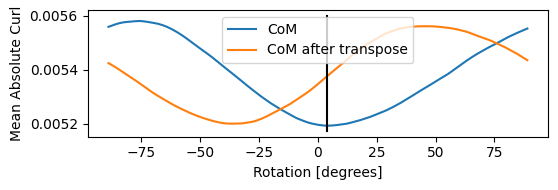

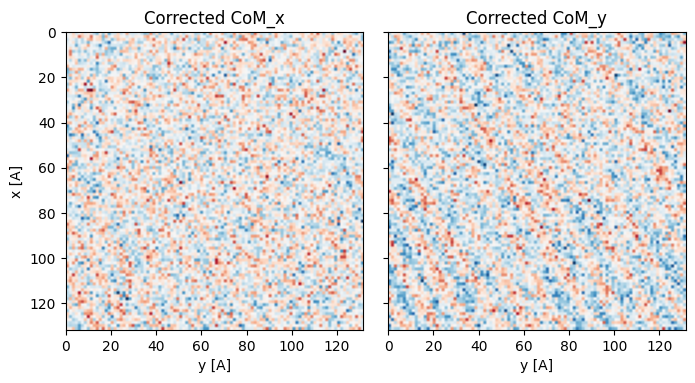

In [8]:
ptycho = ptycho1.preprocess(
    plot_rotation=True,
    plot_center_of_mass = True,
    plot_probe_overlaps = False,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
)

Performing 128 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 128 measurements.
Reconstructing object and probe: 100%|██████████| 128/128 [03:00<00:00,  1.41s/ iter]


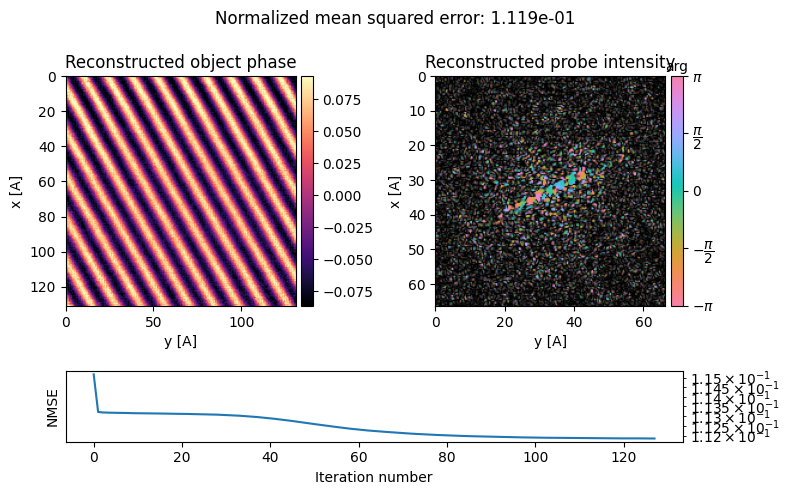

In [9]:
ptycho00 = ptycho.reconstruct(
    num_iter = 128,
    seed_random=0,
    max_batch_size=128,
).visualize(
)

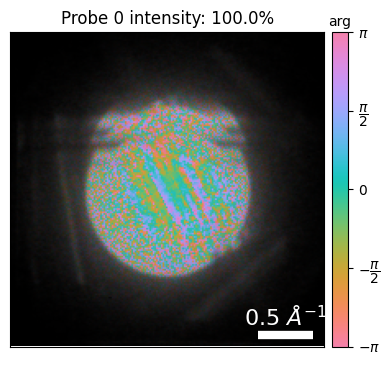

In [10]:
ptycho00.show_fourier_probe()

And investigate how the reconstruction quality degrades if one of rotation, defocus, reciprocal-space calibration is off by 15%

Calculating center of mass: 100%|██████████| 65536/65536 [00:19<00:00, 3355.60probe position/s]
Best fit rotation = -4 degrees.
Normalizing amplitudes: 100%|██████████| 65536/65536 [03:06<00:00, 350.81probe position/s]
Performing 64 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 64/64 [18:08<00:00, 17.01s/ iter]


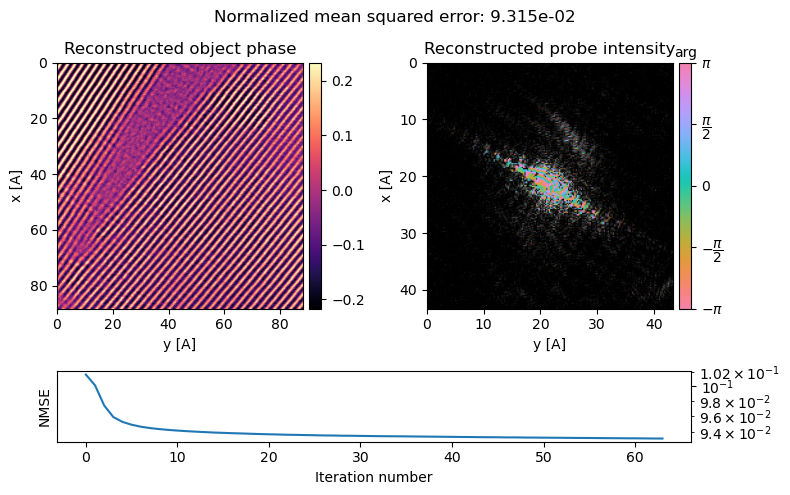

In [52]:
mptycho = py4DSTEM.process.phase.MultislicePtychography(
    energy=300e3,
    num_slices=5,
    slice_thicknesses=10,
    datacube=dataset_masked,
    defocus=0,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)


Calculating center of mass: 100%|██████████| 10000/10000 [00:02<00:00, 3641.23probe position/s]
Best fit rotation = 4 degrees.
Normalizing amplitudes: 100%|██████████| 10000/10000 [00:20<00:00, 476.76probe position/s]
Performing 256 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 256/256 [04:57<00:00,  1.16s/ iter]


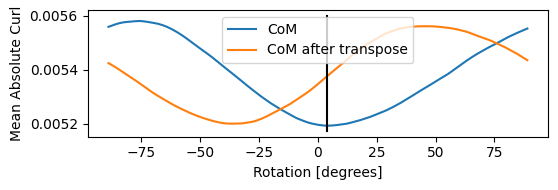

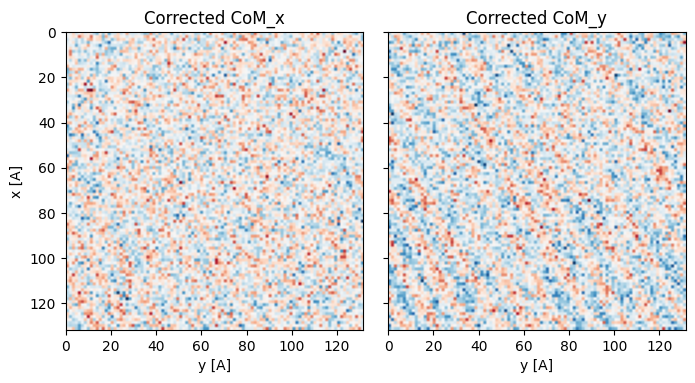

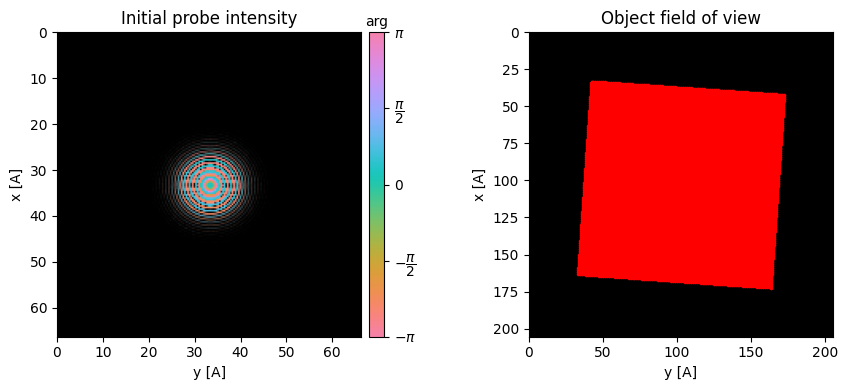

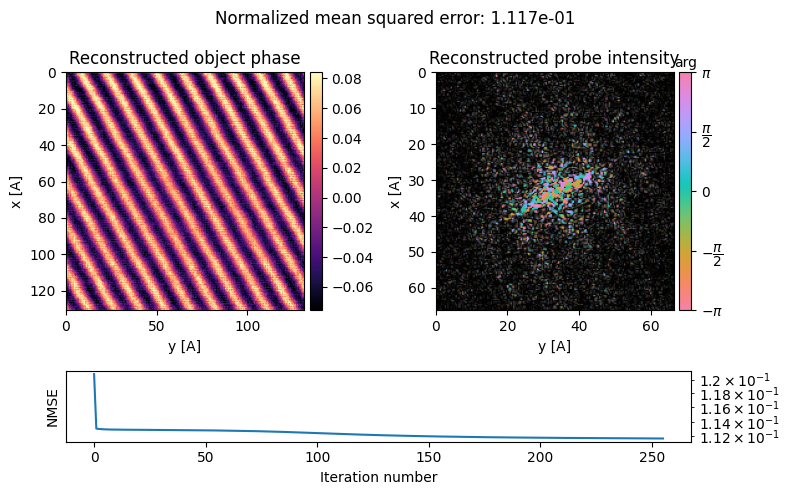

In [11]:
# try:
#     for i in range(10):
#         release_class_gpu_memory()
# except:
#     for i in range(10):
#         release_class_gpu_memory()

mptycho_computational_intense = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset,
    energy=300e3,
    defocus= 15,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = True,
    plot_rotation=True,
    plot_probe_overlaps=True,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 256,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

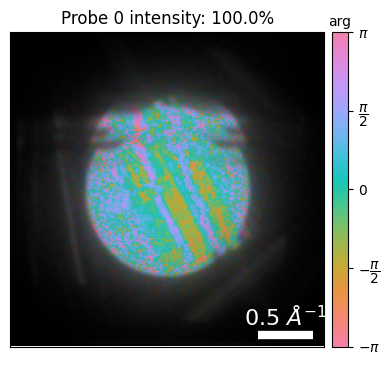

In [14]:
mptycho_computational_intense.show_fourier_probe()

Calculating center of mass: 100%|██████████| 65536/65536 [00:19<00:00, 3356.34probe position/s]
Best fit rotation = -4 degrees.
Normalizing amplitudes: 100%|██████████| 65536/65536 [03:06<00:00, 350.84probe position/s]
Performing 64 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 64/64 [18:08<00:00, 17.00s/ iter]


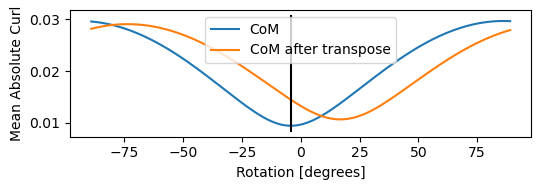

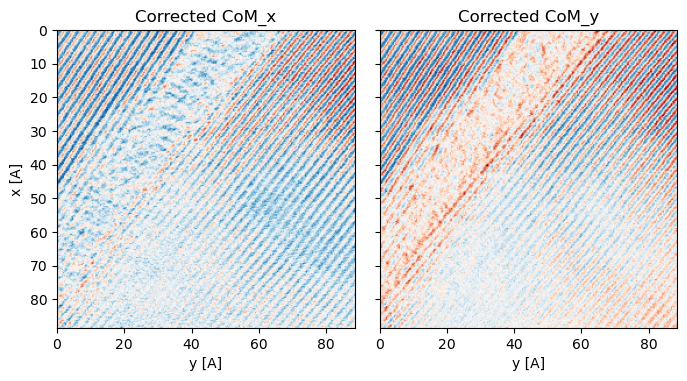

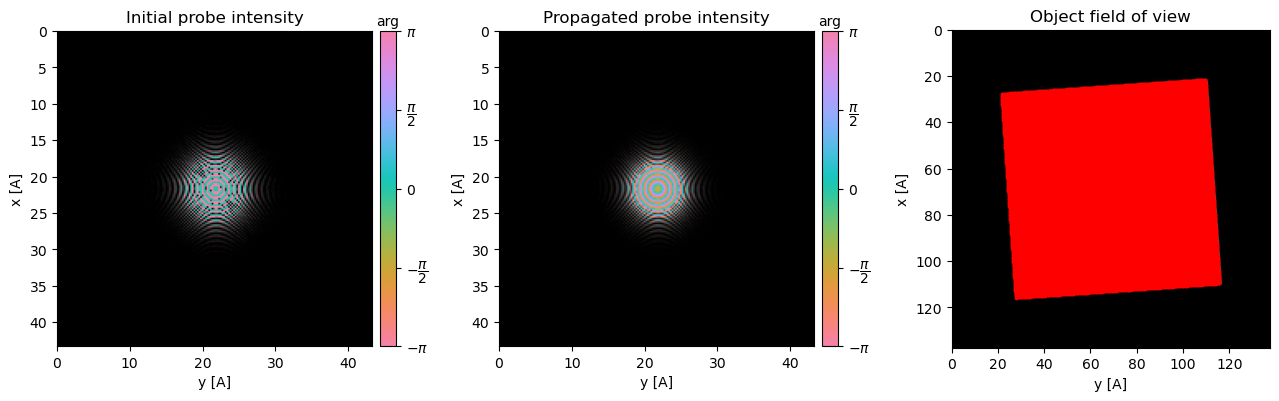

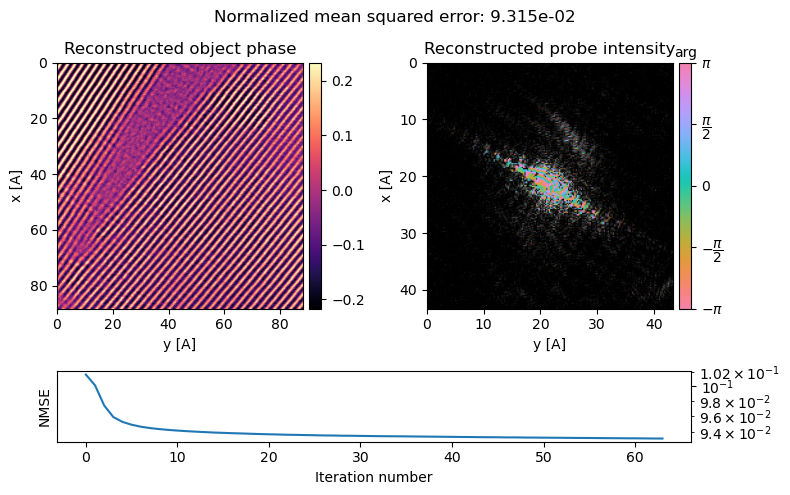

In [54]:
mptycho_intense = py4DSTEM.process.phase.MultislicePtychography(
    energy=300e3,
    num_slices=5,
    slice_thicknesses=10,
    datacube=dataset_masked,
    defocus=0,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = True,
    plot_rotation=True,
    plot_probe_overlaps=True,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

Calculating center of mass: 100%|██████████| 65536/65536 [00:19<00:00, 3341.61probe position/s]
Best fit rotation = -4 degrees.
Normalizing amplitudes: 100%|██████████| 65536/65536 [03:07<00:00, 349.14probe position/s]
Performing 64 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 64/64 [07:10<00:00,  6.73s/ iter]


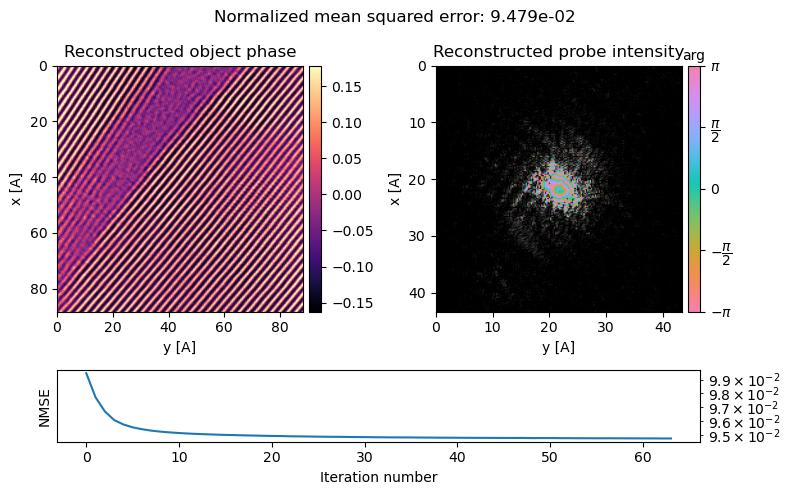

In [55]:
ptycho_bad_defoc = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset_masked,
    energy=300e3,
    defocus=50,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

Calculating center of mass: 100%|██████████| 65536/65536 [00:19<00:00, 3345.53probe position/s]
Best fit rotation = -4 degrees.
Normalizing amplitudes: 100%|██████████| 65536/65536 [03:07<00:00, 349.99probe position/s]
Performing 64 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 64/64 [18:08<00:00, 17.01s/ iter]


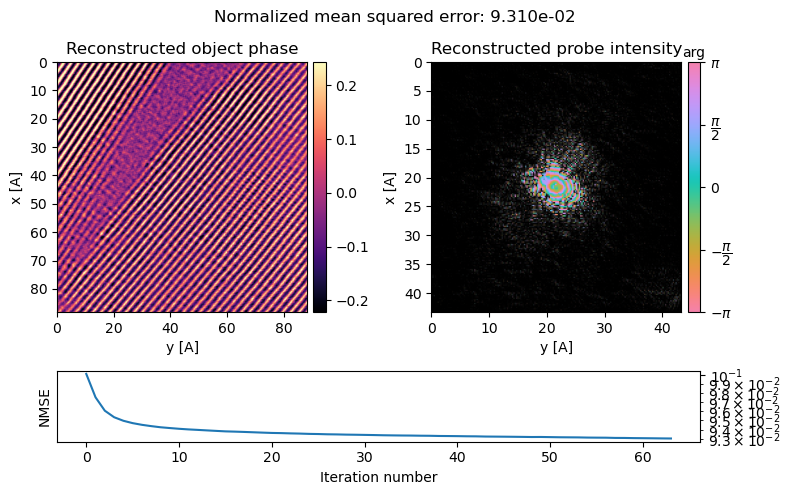

In [56]:
mptycho_bad_Defoc = py4DSTEM.process.phase.MultislicePtychography(
    energy=300e3,
    num_slices=5,
    slice_thicknesses=10,
    datacube=dataset_masked,
    defocus=50,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

Calculating center of mass: 100%|██████████| 65536/65536 [00:19<00:00, 3337.93probe position/s]
Best fit rotation = -4 degrees.
Normalizing amplitudes: 100%|██████████| 65536/65536 [03:08<00:00, 347.66probe position/s]
Performing 64 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 64/64 [07:11<00:00,  6.74s/ iter]


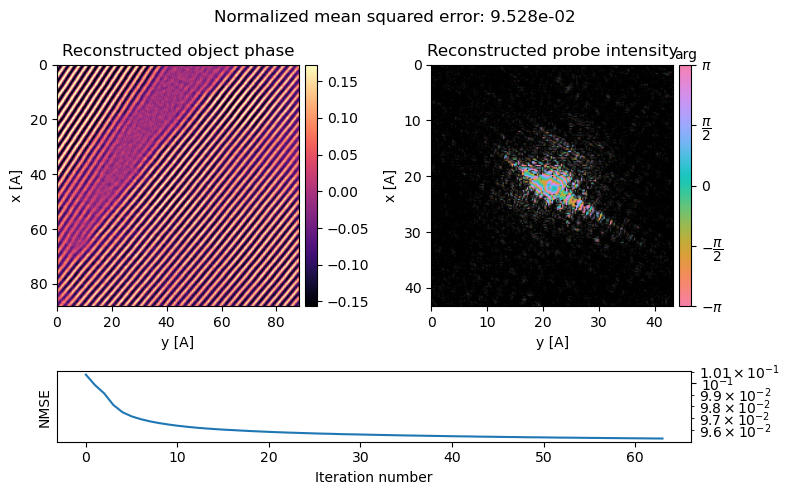

In [57]:
ptycho_bad_defoc2 = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset_masked,
    energy=300e3,
    defocus=-50,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

Calculating center of mass: 100%|██████████| 65536/65536 [00:19<00:00, 3328.92probe position/s]
Best fit rotation = -4 degrees.
Normalizing amplitudes: 100%|██████████| 65536/65536 [03:26<00:00, 317.80probe position/s]
Performing 64 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 512 measurements.
Reconstructing object and probe: 100%|██████████| 64/64 [18:09<00:00, 17.02s/ iter]


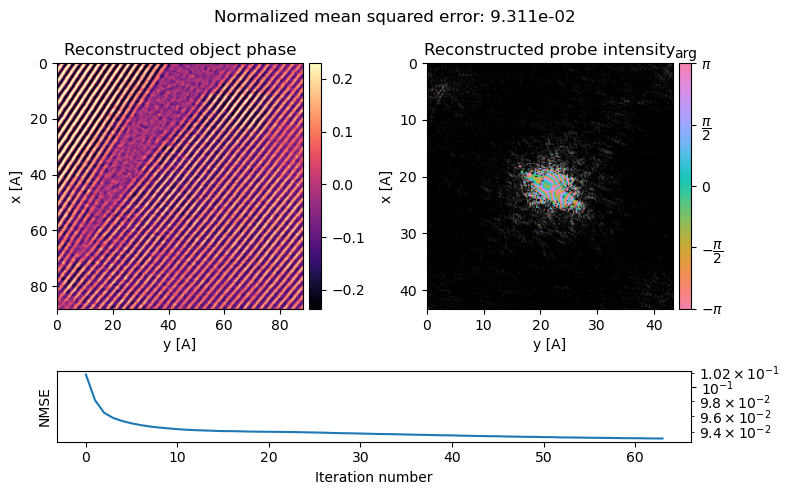

In [58]:
mptycho_bad_Defoc2 = py4DSTEM.process.phase.MultislicePtychography(
    energy=300e3,
    num_slices=5,
    slice_thicknesses=10,
    datacube=dataset_masked,
    defocus=-50,
    vacuum_probe_intensity=probe_nparray,
    verbose=True,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    vectorized_com_calculation = False, # disable default CoM vectorized calc
    store_initial_arrays= False, # don't store arrays necessary for reset=True
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

In [59]:
raise SystemExit('End of script reached. No further processing will be done.')

SystemExit: End of script reached. No further processing will be done.

To exit: use 'exit', 'quit', or Ctrl-D.


Reconstructing object and probe: 100%|██████████| 64/64 [00:13<00:00,  4.87 iter/s]


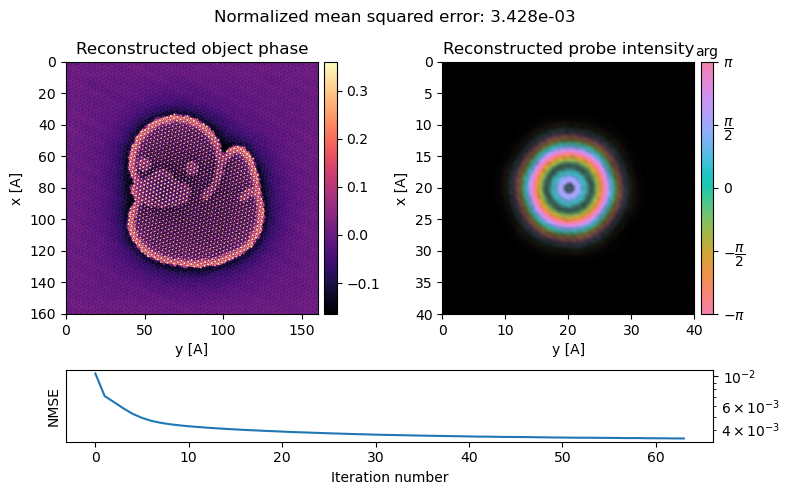

In [9]:
ptycho_wrong_rotation = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset,
    energy=80e3,
    defocus=500,
    vacuum_probe_intensity=probe.data,
    verbose=False,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    plot_center_of_mass = False,
    force_com_rotation = -15*0.85,
    plot_probe_overlaps=False,
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

In [10]:
ptycho_wrong_rotation._object_initial

array([[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j],
       ...,
       [1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j]],
      dtype=complex64)

Reconstructing object and probe: 100%|██████████████████████████████████████| 64/64 [00:38<00:00,  1.68 iter/s]


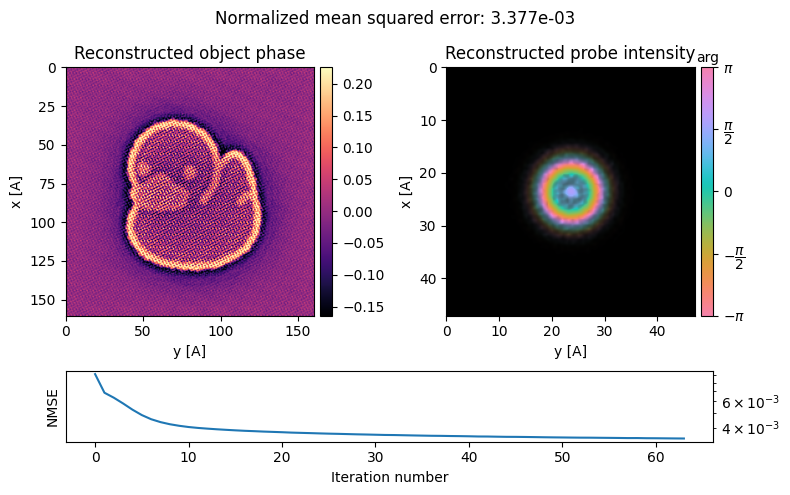

In [ ]:
ptycho_wrong_pixelsize = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=dataset,
    energy=80e3,
    defocus=500,
    vacuum_probe_intensity=probe.data,
    verbose=False,
    device='gpu', # uncomment if you have access to a GPU
    storage='cpu', # uncomment if you have access to a GPU
).preprocess(
    force_reciprocal_sampling=0.025*0.85,
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
).reconstruct(
    num_iter = 64,
    seed_random=0,
    max_batch_size=512,
).visualize(
)

It's interesting to note how more sensitive some calibrations are over others, and how different the failure modes are!

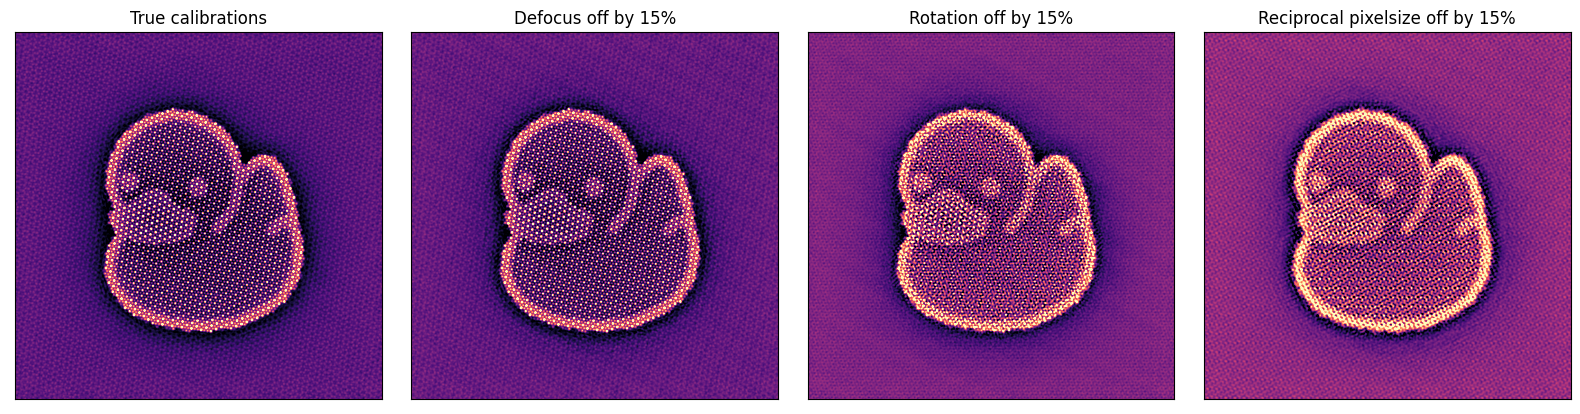

In [ ]:
py4DSTEM.show(
    [
        np.angle(ptycho.object_cropped),
        np.angle(ptycho_wrong_defocus.object_cropped),
        np.angle(ptycho_wrong_rotation.object_cropped),
        np.angle(ptycho_wrong_pixelsize.object_cropped),
    ],
    cmap='magma',
    ticks=False,
    title=["True calibrations","Defocus off by 15%","Rotation off by 15%","Reciprocal pixelsize off by 15%"],
    axsize=(4,4),
)

### Ptychography Optimizer & Optimization Parameter

As we've seen all ptychographic functions in py4DSTEM follow the framework:
```python
XxPtychography(
    **init_args
).preprocess
    **preprocess_args
).reconstruct(
    **reconstruction_args
)
```

The optimizer is thus built around this framework and accepts the ptychographic class as its first argument, followed by the init, preprocess, and reconstruction argument dictionaries
```python
PtychographyOptimizer(
    XxPtychography,
    init_args = init_args,
    preprocess_args = preprocess_args,
    reconstruction_args = reconstruction_args,
)
```

In each dictionary, parameters to be optimized are passed wrapped in an `OptimizationParameter` object, specified as 
```python
OptimizationParameter(
    initial_value,
    lower_bound,
    upper_bound,
)
```
`OptimizationParameter` assumes parameters are real numbers by default, but also supports boolean and integer arguments using the `space` keyword argument. 

Let's translate the ducky parameters to these dictionaries. We'll start with the reciprocal pixel-size, since it's so sensitive.

In [6]:
from py4DSTEM.process.phase.parameter_optimize import OptimizationParameter, PtychographyOptimizer

init_args = {
    'datacube':dataset,
    'energy':80e3,
    'vacuum_probe_intensity':probe.data,
    'device':'gpu',
    'storage':'cpu',
    'defocus':500,
}

preprocess_args = {
    'force_reciprocal_sampling':OptimizationParameter(0.025,0.01,0.04),
    'force_com_rotation': -15,
    'force_com_transpose': False,
}

recon_args = {
    'num_iter':8,
    'max_batch_size':512,
}

optimizer = PtychographyOptimizer(
    py4DSTEM.process.phase.SingleslicePtychography,
    init_args = init_args,
    preprocess_args = preprocess_args,
    reconstruction_args = recon_args,
)

### Grid-search
The simplest optimization is to perform a grid-search. This ignores the `initial_value` argument of `OptimizationParameter` and instead evaluates the ptychography model using equally-distributed `n_points` between the `lower_bound` and `upper_bound`.

Searching parameters: 100%|██████████| 5/5 [00:38<00:00,  7.69s/it]


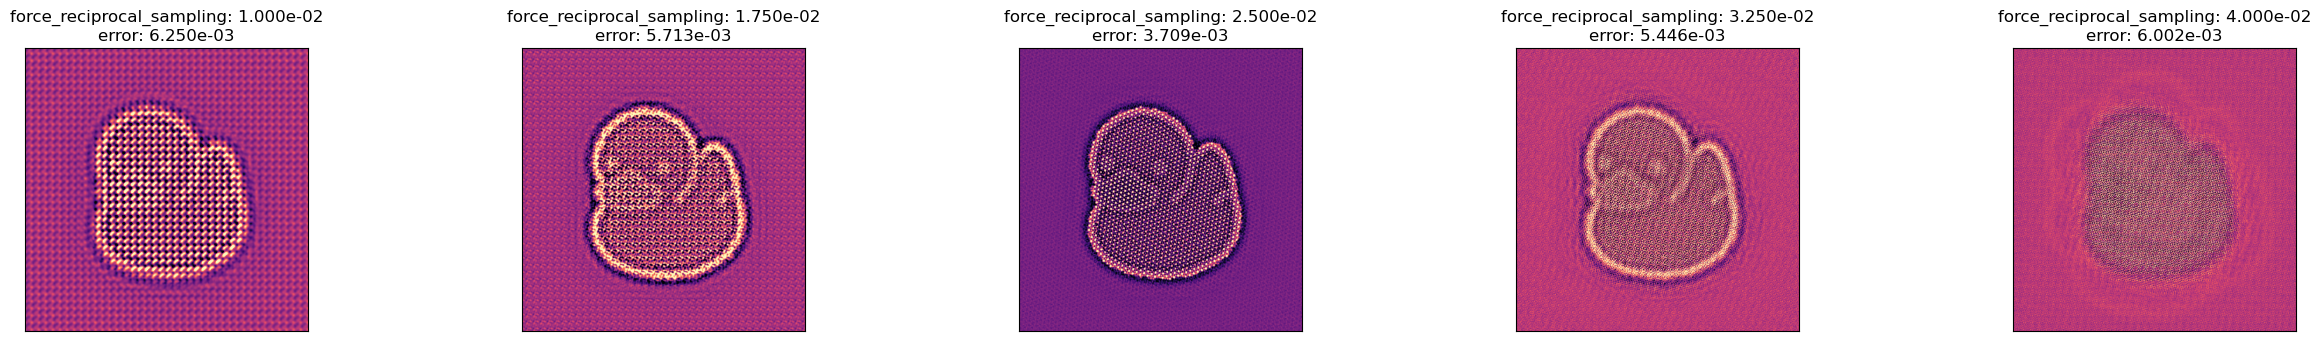

In [7]:
optimizer.grid_search(
    n_points=(5,),
    error_metric="linear",
    plot_reconstructed_objects=True,
    return_reconstructed_objects=False,
    figsize=(25,6.5),
    ncols = 5,
)

We can see the true calibrations demonstrate a global minimum (although note we used a rather aggressive range).

### Bayesian-Optimization with Gaussian Processes

Alternatively, we can perform a more efficient search using Bayesian optimization with Gaussian processes (as implemented in [scikit-optimize](https://scikit-optimize.github.io/stable/)).

In [8]:
optimizer.optimize(
    n_calls=50,
    n_initial_points=15,
    error_metric='log',
)
optimizer = optimizer.visualize()

Optimizing parameters:   2%|▏         | 1/50 [00:13<10:55, 13.38s/it]


KeyboardInterrupt: 

We can also optimize more than one parameters at a time (although note this is not always advisable).  
Here, we optimize defocus and rotation jointly and plot the partial dependence of each parameter on the error metric.

Optimizing parameters: 100%|███████████████████████████████████████████████████| 50/50 [05:07<00:00,  6.16s/it]


Optimized parameters:
defocus: 470.548687501927
force_com_rotation: -15.733333088439176


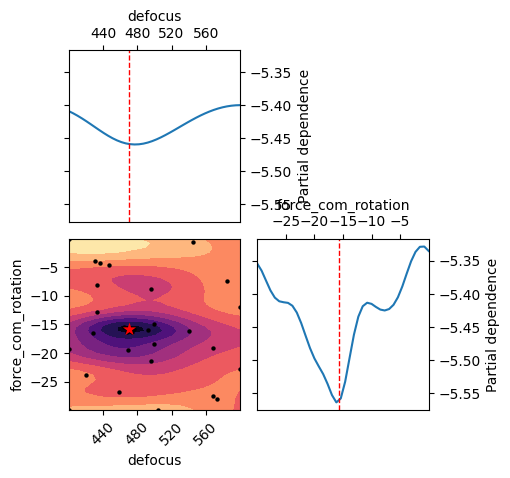

In [ ]:
# Replace/add Optimization parameters in the argument dictionaries
preprocess_args.pop('force_reciprocal_sampling',None)
init_args['defocus']=OptimizationParameter(500,400,600)
preprocess_args['force_com_rotation']=OptimizationParameter(-15,-30,0)

optimizer_defocus_rotation = PtychographyOptimizer(
    py4DSTEM.process.phase.SingleslicePtychography,
    init_args = init_args,
    preprocess_args = preprocess_args,
    reconstruction_args = recon_args,
)

optimizer_defocus_rotation.optimize(
    n_calls=50,
    n_initial_points=15,
    error_metric='log',
)
optimizer_defocus_rotation = optimizer_defocus_rotation.visualize()

Notice how the optimized result is not in-fact the true calibration of 500 A defocus!  
This highlights the risks of blindly using the self-consistency error as an optimization function. To remedy this, `optimize` function accepts an `error_metric` argument, with a variety of predefined and custom metrics.